# 02 — Regionalización de parámetros

Reparte parámetros del **SAND Nacional** entre las 7 regiones usando los archivos de
`Insumos/Mapeo/` como única fuente de configuración. Todos los parámetros pasan por la
misma lógica general — no hay secciones especiales por sector.

**Lógica** (`src/regionalizador.regionalizar_con_mapeo`):

- **Intensivos** (lista en `params_config.yaml`): se copia el valor nacional a cada región
  donde el código exista según `mapeo_tech_fuel.xlsx` (o a las 7 si no hay mapeo).
- **Aditivos**: `valor_regional = valor_nacional × participación`. Los centinelas
  (99999 / solo-9s) se copian sin repartir.
- **Condicionales** (`TotalAnnualMaxCapacityInvestment`, `TotalTechnologyAnnualActivityUpperLimit`,
  `TotalTechnologyModelPeriodActivityUpperLimit`): se resuelven **fila a fila** — si la fila
  nacional es toda ceros o solo-9s se copia (intensivo); si trae valores reales se reparte.
- Los renombramientos del mapeo se aplican al prefijar: si `ELC` se llama `ELC003` en el
  regional, se escribe `AN_ELC003`, no `AN_ELC`.
- Las tecnologías `TRN*` (transmisión interregional) se saltan en silencio: son nuevas por
  diseño del modelo regional, no omisiones.

**Antes de repartir** (Sección 3) se detectan los casos problemáticos y se decide qué hacer
con cada uno; las decisiones quedan auditadas en `reportes/omisiones_regionalizacion.xlsx`.

Salidas: un **SAND reducido** por parámetro en `SANDs_Reducidos/` (o consolidado) y un
**log** de ejecución (Excel + texto) en `reportes/`.

> Ejecutable de principio a fin con *Run All*. Con `MODO_DRY_RUN = True` no escribe nada.

## 1. Setup y configuración de la corrida

In [1]:
# --- Setup: raíz del proyecto y módulos src/ ---
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

RAIZ = Path.cwd().resolve()
if not (RAIZ / "config").exists():   # ejecutado desde notebooks/
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

import comparador
import regionalizador
import reporte
import sand_io
import utils
import yaml_parser

utils.configurar_logging()

## Configuración de rutas

In [ ]:
# --- Configuración de rutas (editar aquí; ya no hay archivo de config de rutas aparte) ---
SAND_NACIONAL       = RAIZ / "SAND_Nacional_base" / "scenario_CN_Nacional_166_Parameters_SAND.xlsx"
SAND_REGIONAL       = RAIZ / "SAND_Regional" / "SAND_Regional_Template_v2.xlsx"
CONFIG_OTOOLE       = RAIZ / "template_config.yaml"
DIR_REPORTES        = RAIZ / "reportes"
DIR_SANDS_REDUCIDOS = RAIZ / "SANDs_Reducidos"

params_cfg = yaml_parser.cargar_params_config(RAIZ / "config" / "params_config.yaml")
otoole = yaml_parser.cargar_config_otoole(CONFIG_OTOOLE)

print(f"Nacional : {SAND_NACIONAL.name}")
print(f"Regional : {SAND_REGIONAL.name}")
print(f"Config otoole: {len(otoole['param'])} parámetros, {len(otoole['set'])} sets")
print(f"Intensivos: {len(params_cfg['parametros_intensivos'])} | "
      f"Condicionales: {len(regionalizador.PARAMS_CONDICIONALES)} | "
      f"Centinela: {params_cfg['valor_centinela']}")

In [ ]:
# --- Variables configurables de la corrida ---

# Lista de parámetros, o la cadena 'todos' para tomar los del SAND nacional
# que estén definidos en el config de otoole.
PARAMETROS_A_REGIONALIZAR =["ResidualCapacity","AccumulatedAnnualDemand","TotalAnnualMinCapacityInvestment","TotalAnnualMaxCapacityInvestment","TotalTechnologyAnnualActivityLowerLimit","TotalTechnologyAnnualActivityUpperLimit","SpecifiedAnnualDemand","SpecifiedDemandProfile","CapitalCost","FixedCost","VariableCost","OutputActivityRatio","InputActivityRatio"]
#,"CapitalCost","FixedCost","VariableCost","OutputActivityRatio","InputActivityRatio"
#

# Filtros de código: acotan qué tecnologías/fuels se regionalizan. [] = sin filtro.
# Cada filtro solo aplica a los parámetros indexados por esa dimensión (un filtro
# de FUEL no toca un parámetro que solo se indexa por TECHNOLOGY, y viceversa).
# Con MODO_FILTRO="contiene" filtran además por SECTOR (ej. ["IND"], ["TRA"], ["RES"]).
TECNOLOGIAS_A_FILTRAR = ["TRA"]              # solo activo si el parámetro se indexa por TECHNOLOGY
FUELS_A_FILTRAR = ["TRA"]                    # solo activo si el parámetro se indexa por FUEL
MODO_FILTRO = "contiene"                  # 'exacto' | 'contiene'

# Códigos que contengan alguno de estos textos NO se regionalizan (ej. ["TRA", "RES"]).
# Es un filtro de exclusión, complementario a los de inclusión de arriba.
SECTORES_A_EXCLUIR = []

MODO_DRY_RUN = False        # True  => no escribe archivos, solo muestra qué haría
MODO_INTERACTIVO = True   # True  => pausa ante cada omisión y pide decisión (Sección 3b)
                           # False => registra las omisiones y continúa sin preguntar

ANIO_MAX = 2054                              # 2055 se excluye (ver CLAUDE.md)
YEARS_FILTRO = list(range(2022, ANIO_MAX + 1))

CONSOLIDADO = False        # True => un solo SAND_Consolidado_*.xlsx
DESCRIPCION = "Mapeo"      # sufijo de los archivos de salida

CARPETA_MAPEO = RAIZ / "Insumos" / "Mapeo"
RUTA_PARTICIPACIONES = CARPETA_MAPEO / "participaciones.xlsx"   # único insumo de participaciones
RUTA_OMISIONES = DIR_REPORTES / "omisiones_regionalizacion.xlsx"

print(f"Dry-run: {MODO_DRY_RUN} | Interactivo: {MODO_INTERACTIVO}")
print(f"Años   : {YEARS_FILTRO[0]}–{YEARS_FILTRO[-1]}")
print(f"Filtro TECHNOLOGY: {TECNOLOGIAS_A_FILTRAR or '(todas)'} | "
      f"FUEL: {FUELS_A_FILTRAR or '(todos)'} | modo: {MODO_FILTRO}")
print(f"Excluir: {SECTORES_A_EXCLUIR or '(nada)'}")

## 2. Cargar SANDs y archivos de mapeo

In [4]:
df_nacional = sand_io.cargar_sand(SAND_NACIONAL)
df_regional = sand_io.cargar_sand(SAND_REGIONAL)
print(f"Nacional: {len(df_nacional):,} filas | Regional: {len(df_regional):,} filas")

# 'todos' => los parámetros del SAND nacional que config_depurado.yaml conoce
if PARAMETROS_A_REGIONALIZAR == "todos":
    PARAMETROS_A_REGIONALIZAR = sorted(
        set(df_nacional["Parameter"].dropna().unique()) & set(otoole["param"]))
    print(f"PARAMETROS_A_REGIONALIZAR = 'todos' -> {len(PARAMETROS_A_REGIONALIZAR)} parámetros")
print(f"A regionalizar: {PARAMETROS_A_REGIONALIZAR}")

Nacional: 23,596 filas | Regional: 20,501 filas
A regionalizar: ['ResidualCapacity', 'AccumulatedAnnualDemand', 'TotalTechnologyAnnualActivityLowerLimit', 'TotalAnnualMaxCapacityInvestment', 'TotalAnnualMinCapacityInvestment', 'TotalAnnualMaxCapacityInvestment', 'TotalTechnologyAnnualActivityLowerLimit', 'TotalTechnologyAnnualActivityUpperLimit', 'SpecifiedAnnualDemand', 'SpecifiedDemandProfile', 'CapitalCost', 'FixedCost', 'VariableCost', 'OutputActivityRatio', 'InputActivityRatio']


In [ ]:
# Participaciones: `Insumos/Mapeo/participaciones.xlsx` es el ÚNICO insumo de
# participaciones del flujo (lo genera 00_Generar_Mapeo.ipynb a partir de los
# Insumos/Participacion_*.xlsx, que son su materia prima, no entrada de aquí).
if not RUTA_PARTICIPACIONES.exists():
    raise FileNotFoundError(
        f"No existe {RUTA_PARTICIPACIONES}. Generarlo con notebooks/00_Generar_Mapeo.ipynb.")
print(f"Participaciones: {RUTA_PARTICIPACIONES.relative_to(RAIZ)}")

df_pct = regionalizador.cargar_participaciones(
    RUTA_PARTICIPACIONES,
    parametros=PARAMETROS_A_REGIONALIZAR,
    params_otoole=otoole["param"],
)
display(df_pct.head(8))

malas = regionalizador.validar_participaciones(df_pct, params_cfg["tolerancia_participacion"])
if malas.empty:
    print("OK: todas las participaciones suman ~1.0 entre regiones")
else:
    display(Markdown(f"**ALERTA: {len(malas)} grupos no suman 1.0**"))
    display(malas.head(20))

In [6]:
# Mapeo: regiones esperadas por código (0/1), renombramientos nacional->regional
# y observaciones de los diccionarios. Los archivos ausentes degradan a None
# (sin mapeo se asumen las 7 regiones y no hay renombramientos).
mapeo = regionalizador.cargar_mapeo_regional(CARPETA_MAPEO)

if mapeo["disponible"]:
    print(f"mapeo_tech_fuel : {len(mapeo['regiones_tech'])} tecnologías, "
          f"{len(mapeo['regiones_fuel'])} fuels")
    renames = {**mapeo["rename_tech"], **mapeo["rename_fuel"]}
    print(f"Renombramientos : {len(renames)}"
          + (f" -> {dict(list(renames.items())[:6])}..." if renames else ""))
else:
    print("Sin mapeo_tech_fuel.xlsx: se asumen las 7 regiones para todo código")
print(f"Observaciones   : {len(mapeo['obs_tech'])} tech, {len(mapeo['obs_fuel'])} fuel")

08:56:05 INFO    comparador: Mapeo cargado: mapeo_tech_fuel.xlsx (507 filas)
08:56:05 INFO    comparador: Mapeo cargado: diccionario_tech.xlsx (509 filas)
08:56:05 INFO    comparador: Mapeo cargado: diccionario_fuel.xlsx (129 filas)
08:56:05 INFO    regionalizador: Mapeo regional: 394 tecnologías, 113 fuels, 14 renombramientos
mapeo_tech_fuel : 394 tecnologías, 113 fuels
Renombramientos : 14 -> {'BDL': 'BDL002', 'BET': 'BET002', 'COA': 'COA001', 'DSL': 'DSL003', 'ELC': 'ELC001', 'ELC002': 'ELC003'}...
Observaciones   : 394 tech, 94 fuel


## 3. Pre-validación y resolución de omisiones

Antes de repartir se identifican los casos problemáticos, uno por (parámetro, código):

| Motivo | Significado |
|---|---|
| `SIN_CORRESPONDENCIA_REGIONAL` | el código nacional no aparece en el regional con ningún prefijo |
| `SIN_PARTICIPACION` | existe en el regional pero no hay % definido para repartirlo |
| `PARTICIPACION_REGION_INEXISTENTE` | hay % > 0 para una región donde el código NO existe (aditivos) |
| `REGIONES_INCOMPLETAS` | existe solo en algunas de las regiones que el mapeo espera |
| `EXCLUIDO_POR_MAPEO` | el mapeo indica que no debe existir — **esperado**, no se pregunta |

### 3a. Detectar omisiones potenciales

In [7]:
omisiones = regionalizador.detectar_omisiones(
    df_nacional, df_regional, df_pct,
    parametros=PARAMETROS_A_REGIONALIZAR,
    params_otoole=otoole["param"], cfg=params_cfg, mapeo=mapeo,
    sectores_a_excluir=SECTORES_A_EXCLUIR,
    tecnologias_filtro=TECNOLOGIAS_A_FILTRAR, fuels_filtro=FUELS_A_FILTRAR,
    modo_filtro=MODO_FILTRO,
)

if omisiones.empty:
    print("Sin omisiones potenciales: todos los códigos tienen correspondencia y participación")
else:
    display(Markdown(f"**{len(omisiones)} omisiones potenciales**"))
    display(omisiones["Motivo"].value_counts().rename("Casos").to_frame())
    display(omisiones.head(20))

08:56:35 INFO    regionalizador: Omisiones potenciales: 98 ({'SIN_PARTICIPACION': 86, 'PARTICIPACION_REGION_INEXISTENTE': 12})


**98 omisiones potenciales**

,Casos
Motivo,
SIN_PARTICIPACION,86
PARTICIPACION_REGION_INEXISTENTE,12


,Parametro,TECHNOLOGY,FUEL,Motivo,Regiones_Existentes,Regiones_Faltantes,Nombre_Regional,Observacion,Decision
0,ResidualCapacity,DEMTRADSLBOT,NaN,SIN_PARTICIPACION,"AN,CA,SE,NE,OR,SO",,,False | IAR solo regional: DSL;GSL002 | solo n...,omitir
1,ResidualCapacity,DEMTRADSLBUS_ART,NaN,SIN_PARTICIPACION,"AN,CA,NE,OR,SO",,,False | IAR solo regional: DSL | solo nacional...,omitir
2,ResidualCapacity,DEMTRADSLBUS_BIA,NaN,SIN_PARTICIPACION,"AN,CA,NE,OR,SO",,,False | IAR solo regional: DSL | solo nacional...,omitir
3,ResidualCapacity,DEMTRADSLBUS_URB,NaN,PARTICIPACION_REGION_INEXISTENTE,"AN,CA,NE,OR,SO","IN,SE",,False | IAR solo regional: DSL | solo nacional...,crear_existentes
4,ResidualCapacity,DEMTRADSLTCK_C2P,NaN,SIN_PARTICIPACION,"AN,CA,SE,IN,NE,OR,SO",,,False | IAR solo regional: DSL | solo nacional: -,omitir
5,ResidualCapacity,DEMTRAELCBOT,NaN,SIN_PARTICIPACION,"AN,CA,SE,NE,OR,SO",,,True,omitir
6,ResidualCapacity,DEMTRAELCBUS_ART,NaN,SIN_PARTICIPACION,"AN,CA,NE,OR,SO",,,True,omitir
7,ResidualCapacity,DEMTRAELCBUS_BIA,NaN,SIN_PARTICIPACION,"AN,CA,NE,OR,SO",,,True,omitir
8,ResidualCapacity,DEMTRAELCBUS_URB,NaN,PARTICIPACION_REGION_INEXISTENTE,"AN,CA,NE,OR,SO","IN,SE",,True,crear_existentes
9,ResidualCapacity,DEMTRAGSLBOT,NaN,SIN_PARTICIPACION,"AN,CA,SE,NE,OR,SO",,,False | IAR solo regional: GSL | solo nacional: -,omitir


### 3b. Resolución de omisiones

Con `MODO_INTERACTIVO = True` se pregunta caso por caso (los `EXCLUIDO_POR_MAPEO` se
saltan, son esperados):

- `[1]` crear en todas las regiones faltantes, con participación uniforme `1/N`
  (en `PARTICIPACION_REGION_INEXISTENTE`: crear el código en las regiones a las que el
  archivo les asigna %, usando ese % real y no `1/N`)
- `[2]` crear solo en las regiones indicadas (ej. `AN,CA`)
- `[3]` no crear: omitir el caso (en `PARTICIPACION_REGION_INEXISTENTE` significa omitir
  solo esas regiones y emitir en las existentes, perdiendo su fracción de %)
- `[4]` aplicar ese "no crear" a todos los casos restantes del mismo motivo
- `[5]` crear en las regiones **existentes**; el reparto depende del motivo:
  - `REGIONES_INCOMPLETAS`: usa las participaciones del archivo **tal cual, sin
    renormalizar** — la fracción de las regiones faltantes se pierde (la suma regional
    queda por debajo del nacional y el comparador lo reportará, es intencional). Si no hay
    % aplicable a las existentes NO se inventa reparto: queda vacío con `ADVERTENCIA`.
  - `SIN_PARTICIPACION`: reparte **uniforme `1/N`** entre las regiones existentes (aquí no
    hay % en el archivo que reutilizar).

Tras cualquier opción explícita (`[1]`/`[2]`/`[3]`/`[5]`) se pregunta si se aplica **a todos
los casos restantes de ese mismo motivo** (`s/N`); la `[4]` es el atajo directo para hacerlo
con el "no crear" del motivo.

Con `MODO_INTERACTIVO = False` todo queda en `omitir` y el flujo continúa. En ambos casos
las decisiones se exportan para auditoría — también con `MODO_DRY_RUN = True`, ya que este
archivo es justamente lo que hay que revisar antes de una corrida real.

In [8]:
omisiones = regionalizador.resolver_omisiones(omisiones, interactivo=MODO_INTERACTIVO)

if not omisiones.empty:
    display(Markdown("**Decisiones tomadas**"))
    display(omisiones["Decision"].value_counts().rename("Casos").to_frame())

    RUTA_OMISIONES.parent.mkdir(parents=True, exist_ok=True)
    omisiones.to_excel(RUTA_OMISIONES, index=False)
    print(f"Auditoría: {RUTA_OMISIONES}")


[1/98] SIN_PARTICIPACION — ResidualCapacity
  TECHNOLOGY=DEMTRADSLBOT  FUEL=nan
  Existe en : AN,CA,SE,NE,OR,SO
  Falta en : (ninguna)
  Diccionario: False | IAR solo regional: DSL;GSL002 | solo nacional: DSL002
  [1] crear en todas las faltantes (1/N)  [2] crear en regiones...  [3] omitir  [4] omitir todos los de este motivo

[2/98] SIN_PARTICIPACION — ResidualCapacity
  TECHNOLOGY=DEMTRADSLBUS_ART  FUEL=nan
  Existe en : AN,CA,NE,OR,SO
  Falta en : (ninguna)
  Diccionario: False | IAR solo regional: DSL | solo nacional: DSL002
  [1] crear en todas las faltantes (1/N)  [2] crear en regiones...  [3] omitir  [4] omitir todos los de este motivo

[3/98] SIN_PARTICIPACION — ResidualCapacity
  TECHNOLOGY=DEMTRADSLBUS_BIA  FUEL=nan
  Existe en : AN,CA,NE,OR,SO
  Falta en : (ninguna)
  Diccionario: False | IAR solo regional: DSL | solo nacional: DSL002
  [1] crear en todas las faltantes (1/N)  [2] crear en regiones...  [3] omitir  [4] omitir todos los de este motivo

[4/98] PARTICIPACION_REG

**Decisiones tomadas**

,Casos
Decision,
"crear_regiones:AN,CA,NE,OR,SO",85
crear_existentes,12
"crear_regiones:AN,CA,SE,NE,OR,SO",1


Auditoría: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\reportes\omisiones_regionalizacion.xlsx


## 4. Regionalización

In [9]:
resultado = regionalizador.regionalizar_con_mapeo(
    df_nacional, df_regional, df_pct,
    parametros=PARAMETROS_A_REGIONALIZAR,
    params_otoole=otoole["param"], cfg=params_cfg, mapeo=mapeo,
    omisiones=omisiones,
    years_filtro=YEARS_FILTRO,
    sectores_a_excluir=SECTORES_A_EXCLUIR,
    tecnologias_filtro=TECNOLOGIAS_A_FILTRAR, fuels_filtro=FUELS_A_FILTRAR,
    modo_filtro=MODO_FILTRO,
)
sands, log, resumen = resultado["sands"], resultado["log"], resultado["resumen"]

display(Markdown("**Resumen por parámetro**"))
display(resumen)
display(Markdown("**Log de regionalización**"))
display(log)

08:59:33 WARNING regionalizador: 298 grupos de participación no suman 1.0 (tolerancia 0.001)
08:59:37 INFO    regionalizador: ResidualCapacity: 63 combos, 360 filas, 0 omitidos, 23 creados
08:59:37 INFO    regionalizador: AccumulatedAnnualDemand: 13 combos, 74 filas, 0 omitidos, 3 creados


C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\src\regionalizador.py:1112: PerformanceWarning: indexing past lexsort depth may impact performance.
  p = pct_combo.get((prefijo, anio))


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
for parametro, df_sand in sands.items():
    display(Markdown(f"**{parametro}** — {len(df_sand):,} filas SAND"))
    display(df_sand.head(8))

**TotalAnnualMaxCapacityInvestment** — 366 filas SAND

,Parameter,REGION,TECHNOLOGY,EMISSION,MODE_OF_OPERATION,FUEL,TIMESLICE,STORAGE,REGION2,Time indipendent variables,...,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055
0,TotalAnnualMaxCapacityInvestment,RE1,AN_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
1,TotalAnnualMaxCapacityInvestment,RE1,CA_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
2,TotalAnnualMaxCapacityInvestment,RE1,NE_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
3,TotalAnnualMaxCapacityInvestment,RE1,OR_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
4,TotalAnnualMaxCapacityInvestment,RE1,SE_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
5,TotalAnnualMaxCapacityInvestment,RE1,SO_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
6,TotalAnnualMaxCapacityInvestment,RE1,AN_DEMTRADSLBUS_ART,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
7,TotalAnnualMaxCapacityInvestment,RE1,CA_DEMTRADSLBUS_ART,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>


**TotalTechnologyAnnualActivityUpperLimit** — 366 filas SAND

,Parameter,REGION,TECHNOLOGY,EMISSION,MODE_OF_OPERATION,FUEL,TIMESLICE,STORAGE,REGION2,Time indipendent variables,...,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055
0,TotalTechnologyAnnualActivityUpperLimit,RE1,AN_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
1,TotalTechnologyAnnualActivityUpperLimit,RE1,CA_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
2,TotalTechnologyAnnualActivityUpperLimit,RE1,NE_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
3,TotalTechnologyAnnualActivityUpperLimit,RE1,OR_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
4,TotalTechnologyAnnualActivityUpperLimit,RE1,SE_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
5,TotalTechnologyAnnualActivityUpperLimit,RE1,SO_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
6,TotalTechnologyAnnualActivityUpperLimit,RE1,AN_DEMTRADSLBUS_ART,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>
7,TotalTechnologyAnnualActivityUpperLimit,RE1,CA_DEMTRADSLBUS_ART,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,"99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000","99,999.000000",<NA>


**SpecifiedDemandProfile** — 3 filas SAND

...

,Parameter,REGION,TECHNOLOGY,EMISSION,MODE_OF_OPERATION,FUEL,TIMESLICE,STORAGE,REGION2,Time indipendent variables,...,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055
0,FixedCost,RE1,AN_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
1,FixedCost,RE1,CA_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
2,FixedCost,RE1,NE_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
3,FixedCost,RE1,OR_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
4,FixedCost,RE1,SE_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
5,FixedCost,RE1,SO_DEMTRADSLBOT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
6,FixedCost,RE1,AN_DEMTRADSLBUS_ART,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,592.934650,616.652000,641.318450,666.971300,693.649750,721.396150,750.251650,780.261750,811.472600,<NA>
7,FixedCost,RE1,CA_DEMTRADSLBUS_ART,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,592.934650,616.652000,641.318450,666.971300,693.649750,721.396150,750.251650,780.261750,811.472600,<NA>


**VariableCost** — 366 filas SAND

,Parameter,REGION,TECHNOLOGY,EMISSION,MODE_OF_OPERATION,FUEL,TIMESLICE,STORAGE,REGION2,Time indipendent variables,...,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055
0,VariableCost,RE1,AN_DEMTRADSLBOT,<NA>,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
1,VariableCost,RE1,CA_DEMTRADSLBOT,<NA>,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
2,VariableCost,RE1,NE_DEMTRADSLBOT,<NA>,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
3,VariableCost,RE1,OR_DEMTRADSLBOT,<NA>,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
4,VariableCost,RE1,SE_DEMTRADSLBOT,<NA>,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
5,VariableCost,RE1,SO_DEMTRADSLBOT,<NA>,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
6,VariableCost,RE1,AN_DEMTRADSLBUS_ART,<NA>,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>
7,VariableCost,RE1,CA_DEMTRADSLBUS_ART,<NA>,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>


**OutputActivityRatio** — 366 filas SAND

,Parameter,REGION,TECHNOLOGY,EMISSION,MODE_OF_OPERATION,FUEL,TIMESLICE,STORAGE,REGION2,Time indipendent variables,...,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055
0,OutputActivityRatio,RE1,AN_DEMTRADSLBOT,<NA>,1.000000,AN_TRARVT,<NA>,<NA>,<NA>,<NA>,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,<NA>
1,OutputActivityRatio,RE1,CA_DEMTRADSLBOT,<NA>,1.000000,CA_TRARVT,<NA>,<NA>,<NA>,<NA>,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,<NA>
2,OutputActivityRatio,RE1,NE_DEMTRADSLBOT,<NA>,1.000000,NE_TRARVT,<NA>,<NA>,<NA>,<NA>,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,<NA>
3,OutputActivityRatio,RE1,OR_DEMTRADSLBOT,<NA>,1.000000,OR_TRARVT,<NA>,<NA>,<NA>,<NA>,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,<NA>
4,OutputActivityRatio,RE1,SE_DEMTRADSLBOT,<NA>,1.000000,SE_TRARVT,<NA>,<NA>,<NA>,<NA>,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,<NA>
5,OutputActivityRatio,RE1,SO_DEMTRADSLBOT,<NA>,1.000000,SO_TRARVT,<NA>,<NA>,<NA>,<NA>,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,<NA>
6,OutputActivityRatio,RE1,AN_DEMTRADSLBUS_ART,<NA>,1.000000,AN_TRAMAS,<NA>,<NA>,<NA>,<NA>,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,<NA>
7,OutputActivityRatio,RE1,CA_DEMTRADSLBUS_ART,<NA>,1.000000,CA_TRAMAS,<NA>,<NA>,<NA>,<NA>,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,<NA>


## 5. Gráficas de control

Una gráfica por parámetro efectivamente regionalizado: barras apiladas por región a lo
largo de los años, con un panel por código base (FUEL o TECHNOLOGY según los índices del
parámetro). Si hay más de 20 códigos se muestran los top-10 por valor total y el resto se
agrega en "Otros".

⚠ **ResidualCapacity** no tiene datos regionalizados — revisar `omisiones_regionalizacion.xlsx`

⚠ **AccumulatedAnnualDemand** no tiene datos regionalizados — revisar `omisiones_regionalizacion.xlsx`

⚠ **TotalTechnologyAnnualActivityLowerLimit** no tiene datos regionalizados — revisar `omisiones_regionalizacion.xlsx`

04:16:35 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:35 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:35 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:35 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:35 INFO    matplotlib.category: Using categorical units to plot a list of strings 

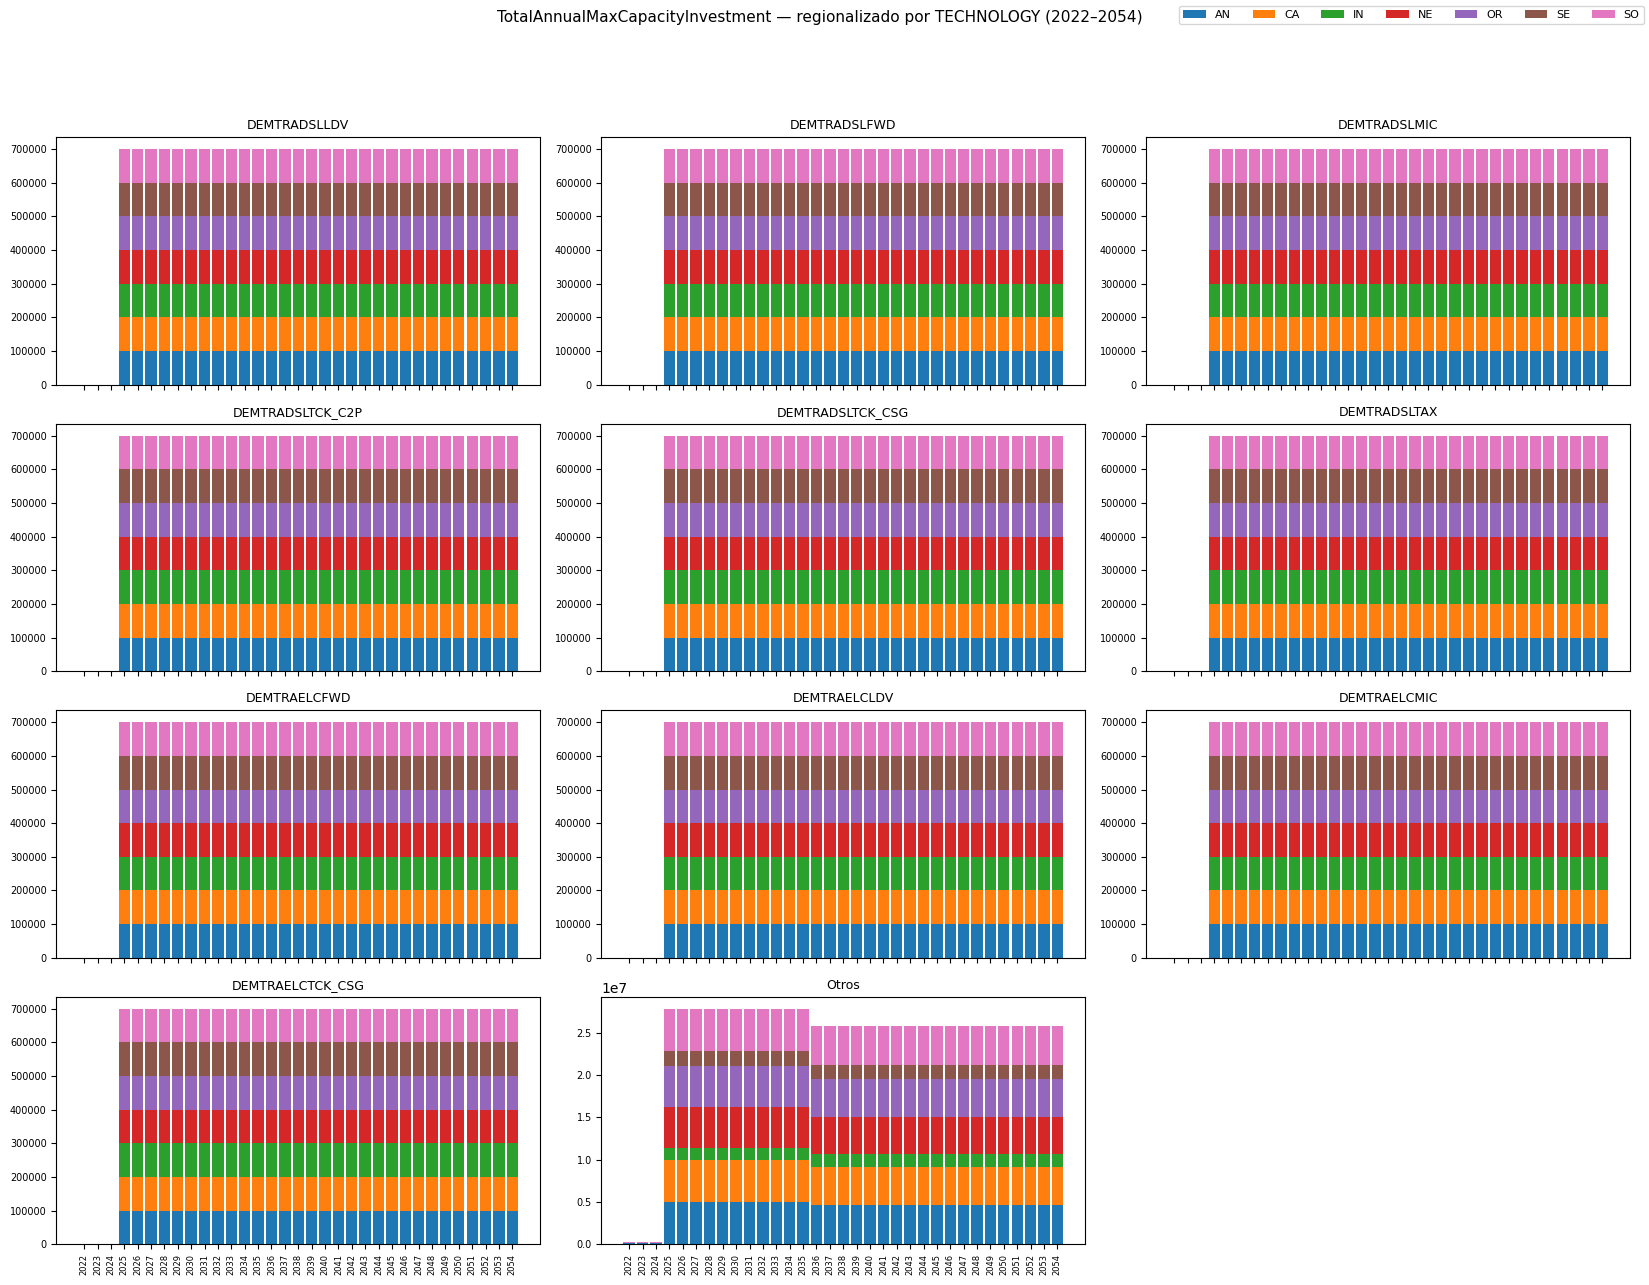

⚠ **TotalAnnualMinCapacityInvestment** no tiene datos regionalizados — revisar `omisiones_regionalizacion.xlsx`

04:16:41 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:41 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:41 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:41 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:41 INFO    matplotlib.category: Using categorical units to plot a list of strings 

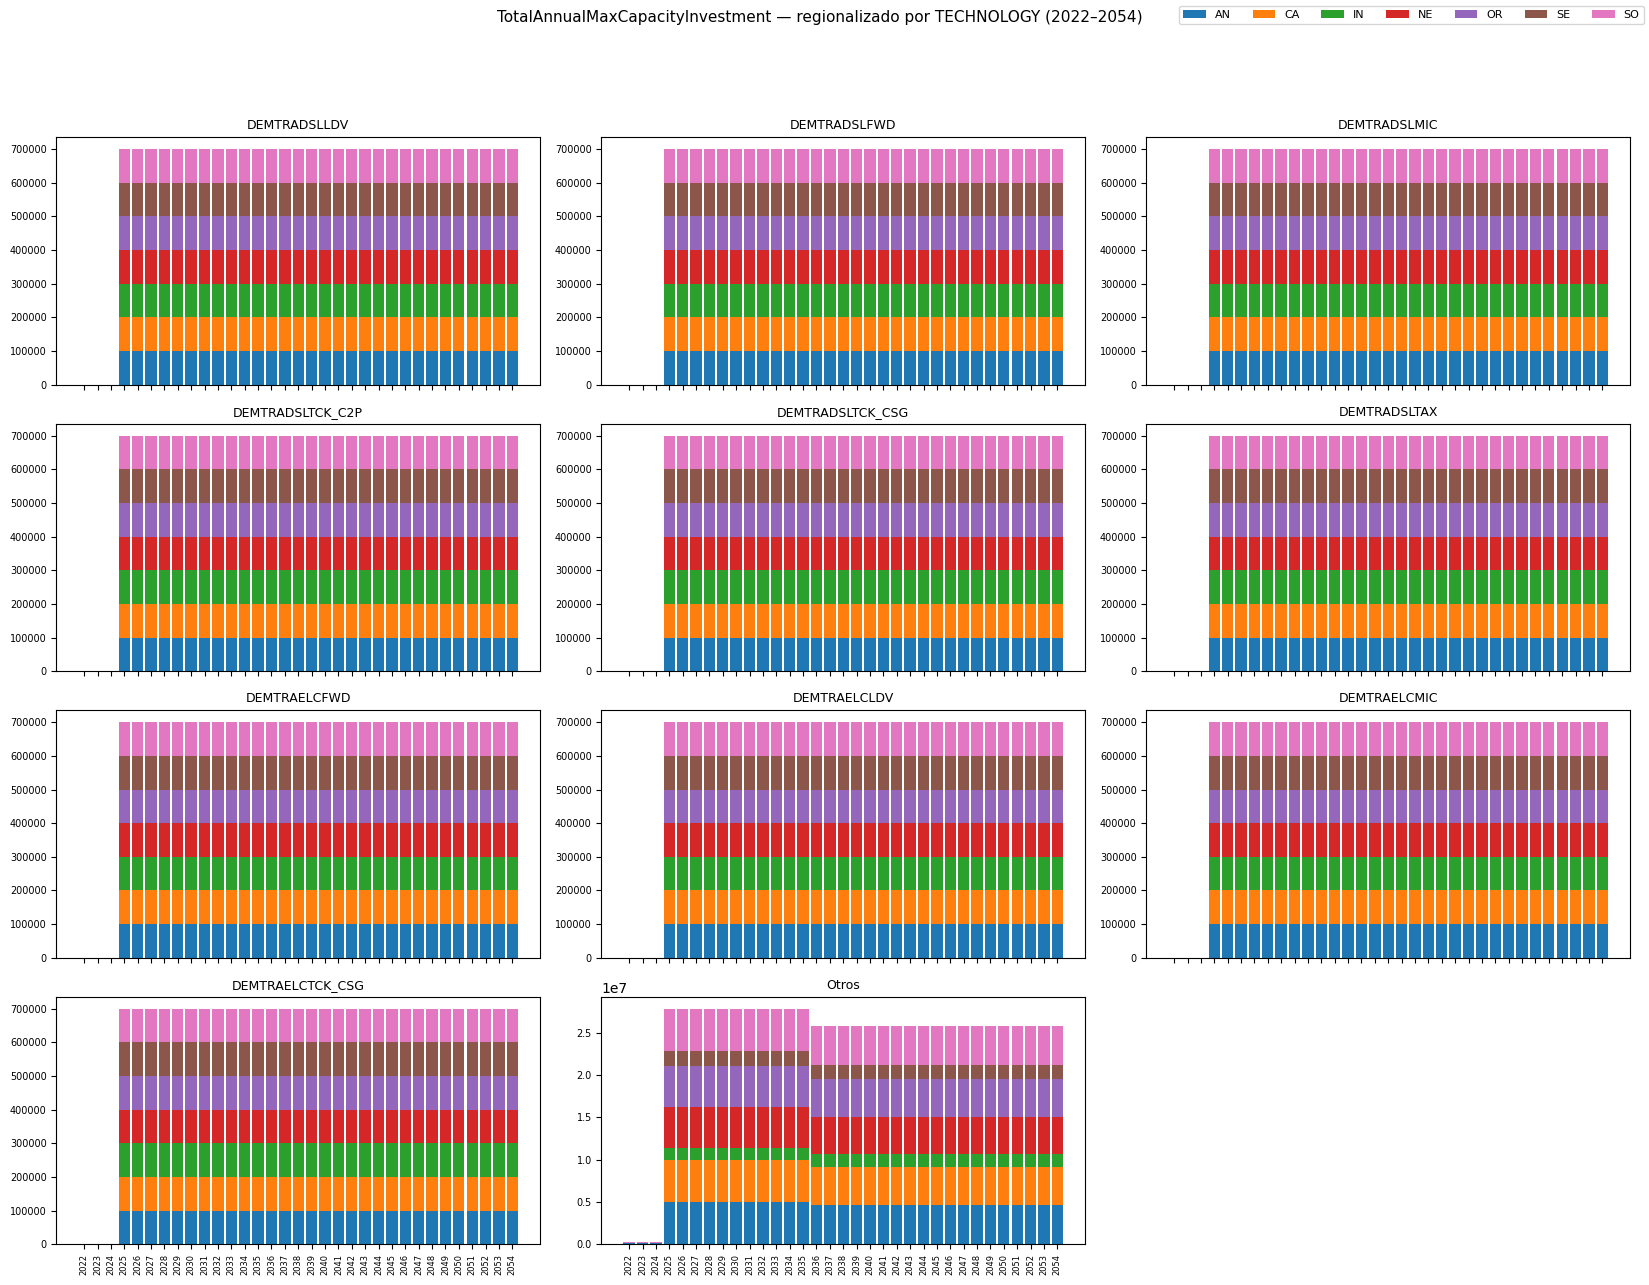

⚠ **TotalTechnologyAnnualActivityLowerLimit** no tiene datos regionalizados — revisar `omisiones_regionalizacion.xlsx`

04:16:49 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:49 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:49 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:49 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:49 INFO    matplotlib.category: Using categorical units to plot a list of strings 

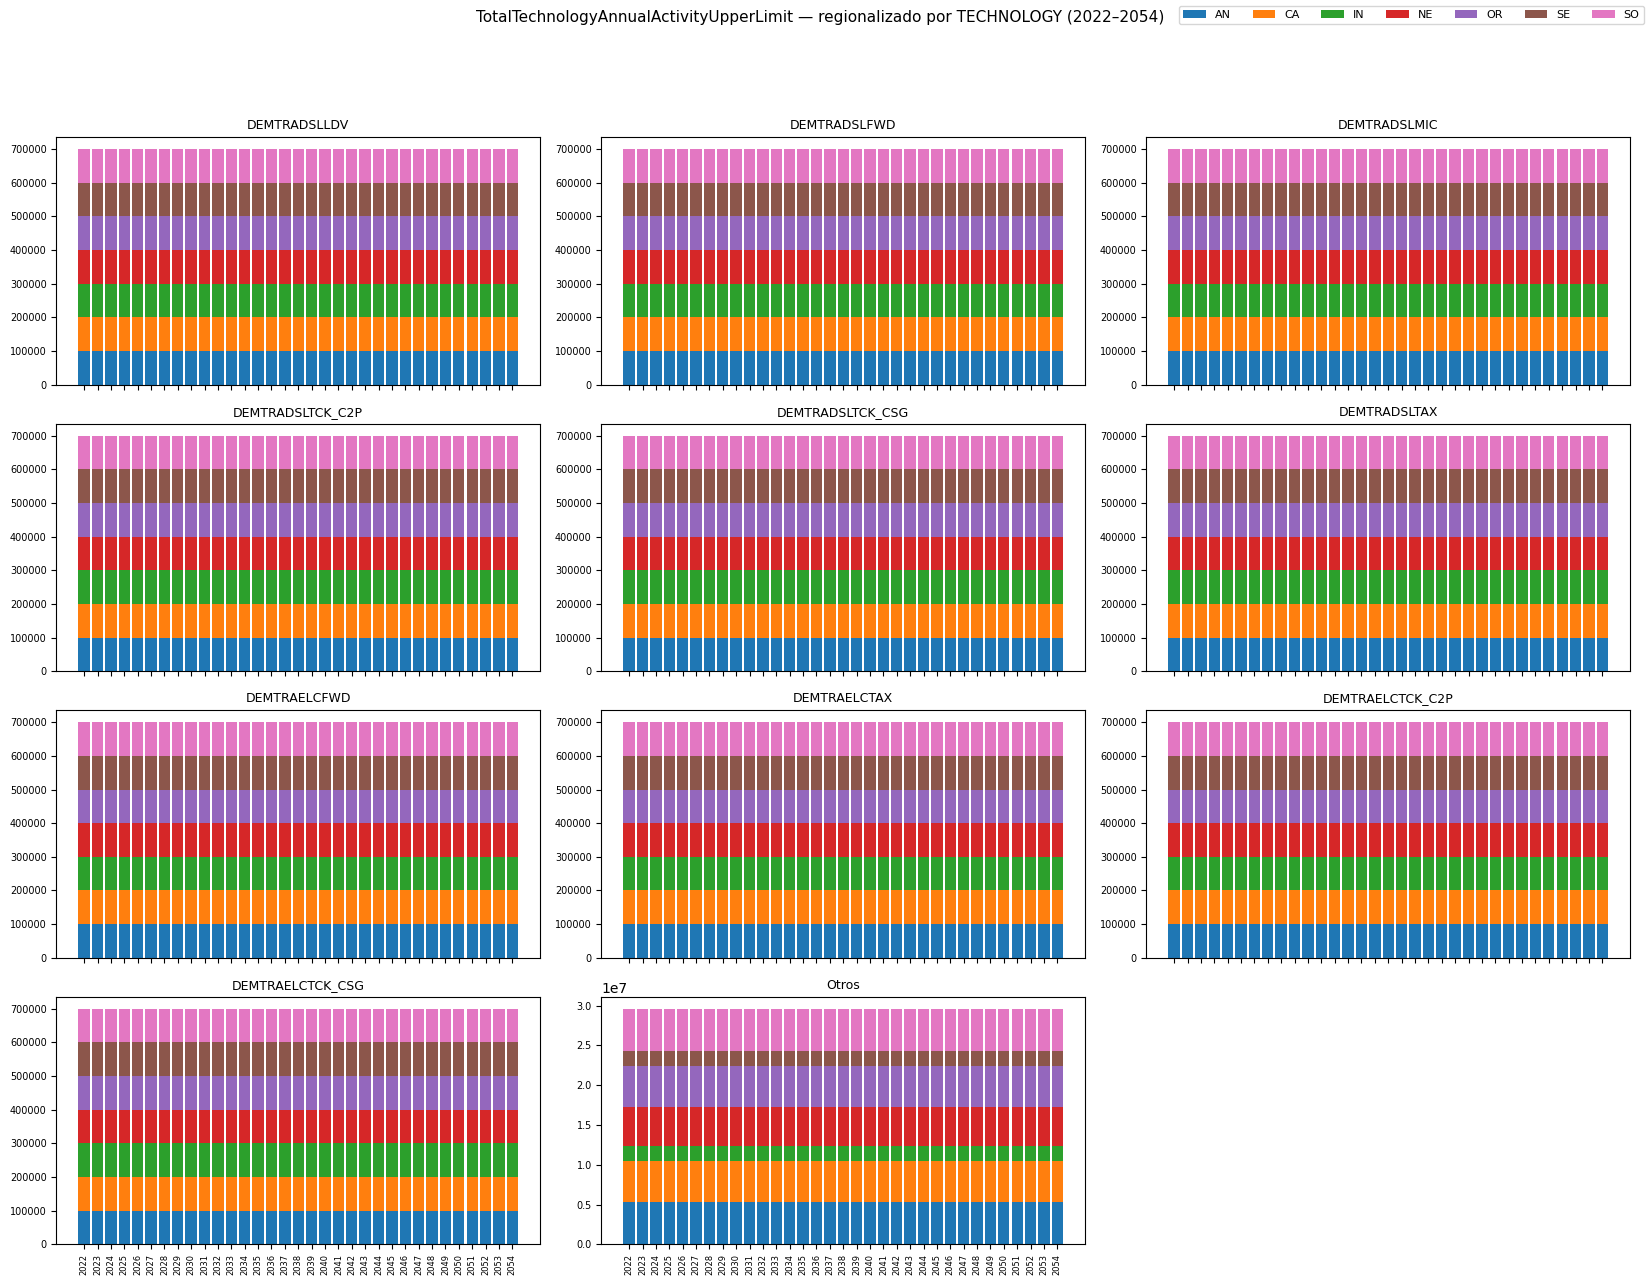

⚠ **SpecifiedAnnualDemand** no tiene datos regionalizados — revisar `omisiones_regionalizacion.xlsx`

04:16:57 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:57 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:57 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:57 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


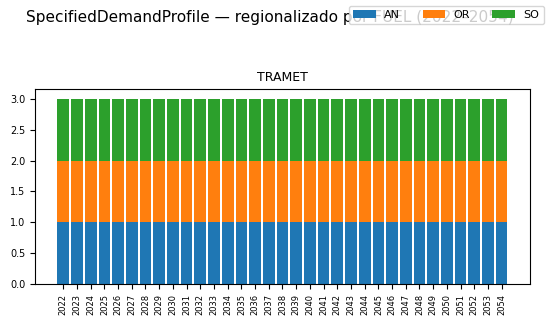

04:16:57 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:57 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:57 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:57 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:16:57 INFO    matplotlib.category: Using categorical units to plot a list of strings 

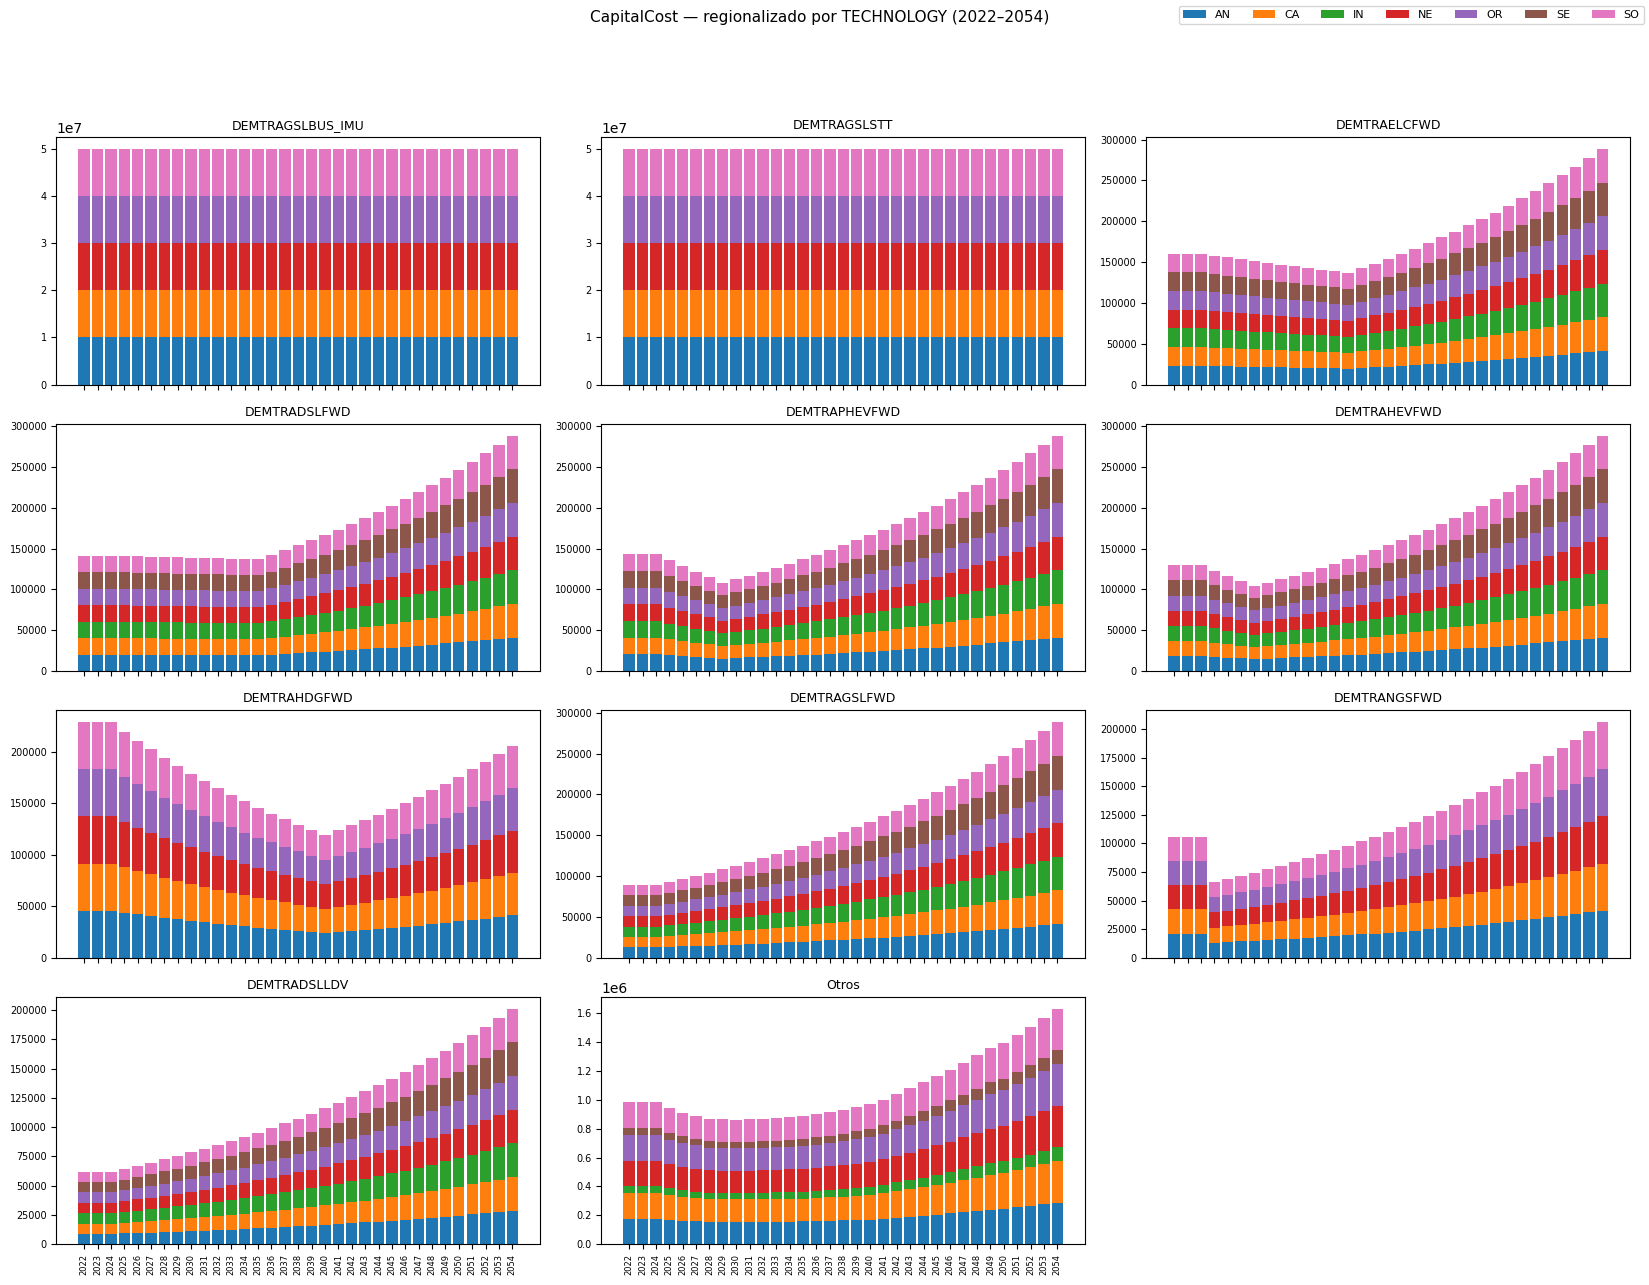

04:17:05 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:05 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:05 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:05 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:05 INFO    matplotlib.category: Using categorical units to plot a list of strings 

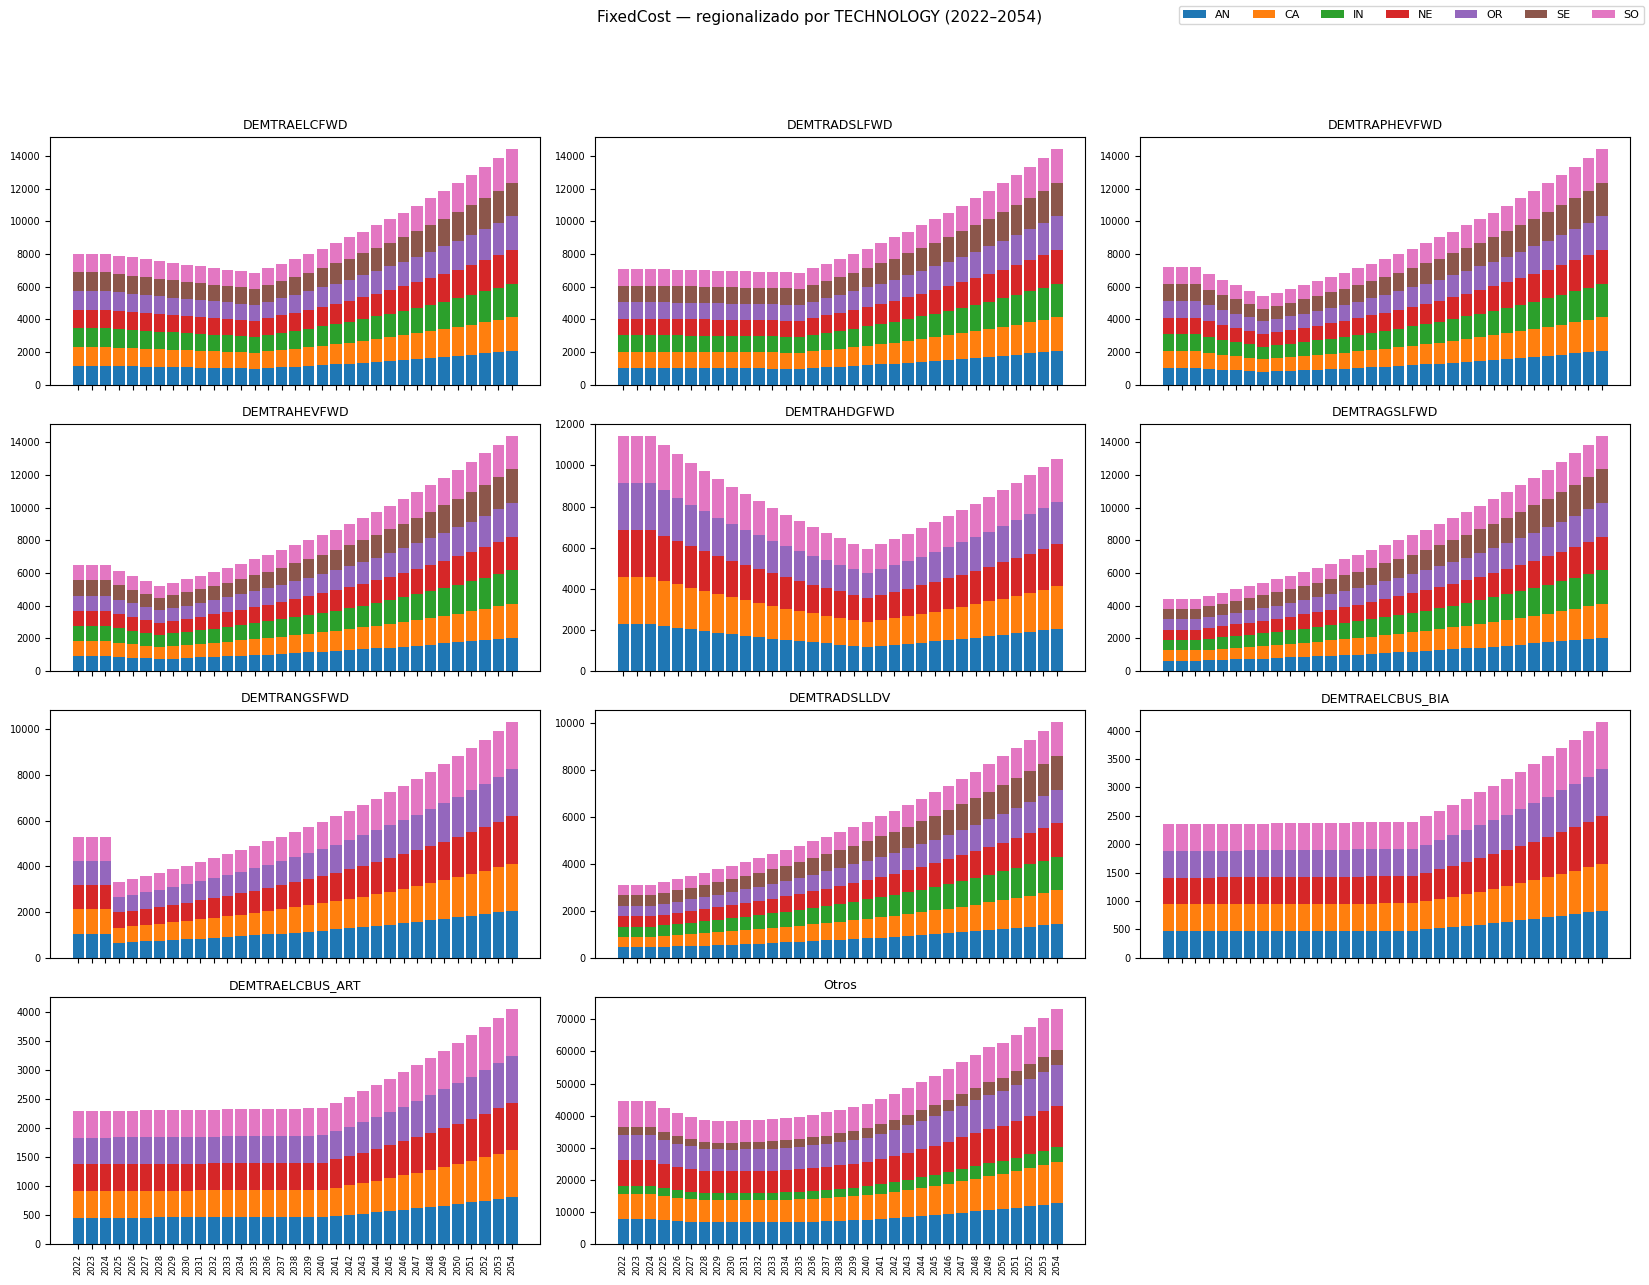

04:17:12 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:12 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:12 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:12 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:12 INFO    matplotlib.category: Using categorical units to plot a list of strings 

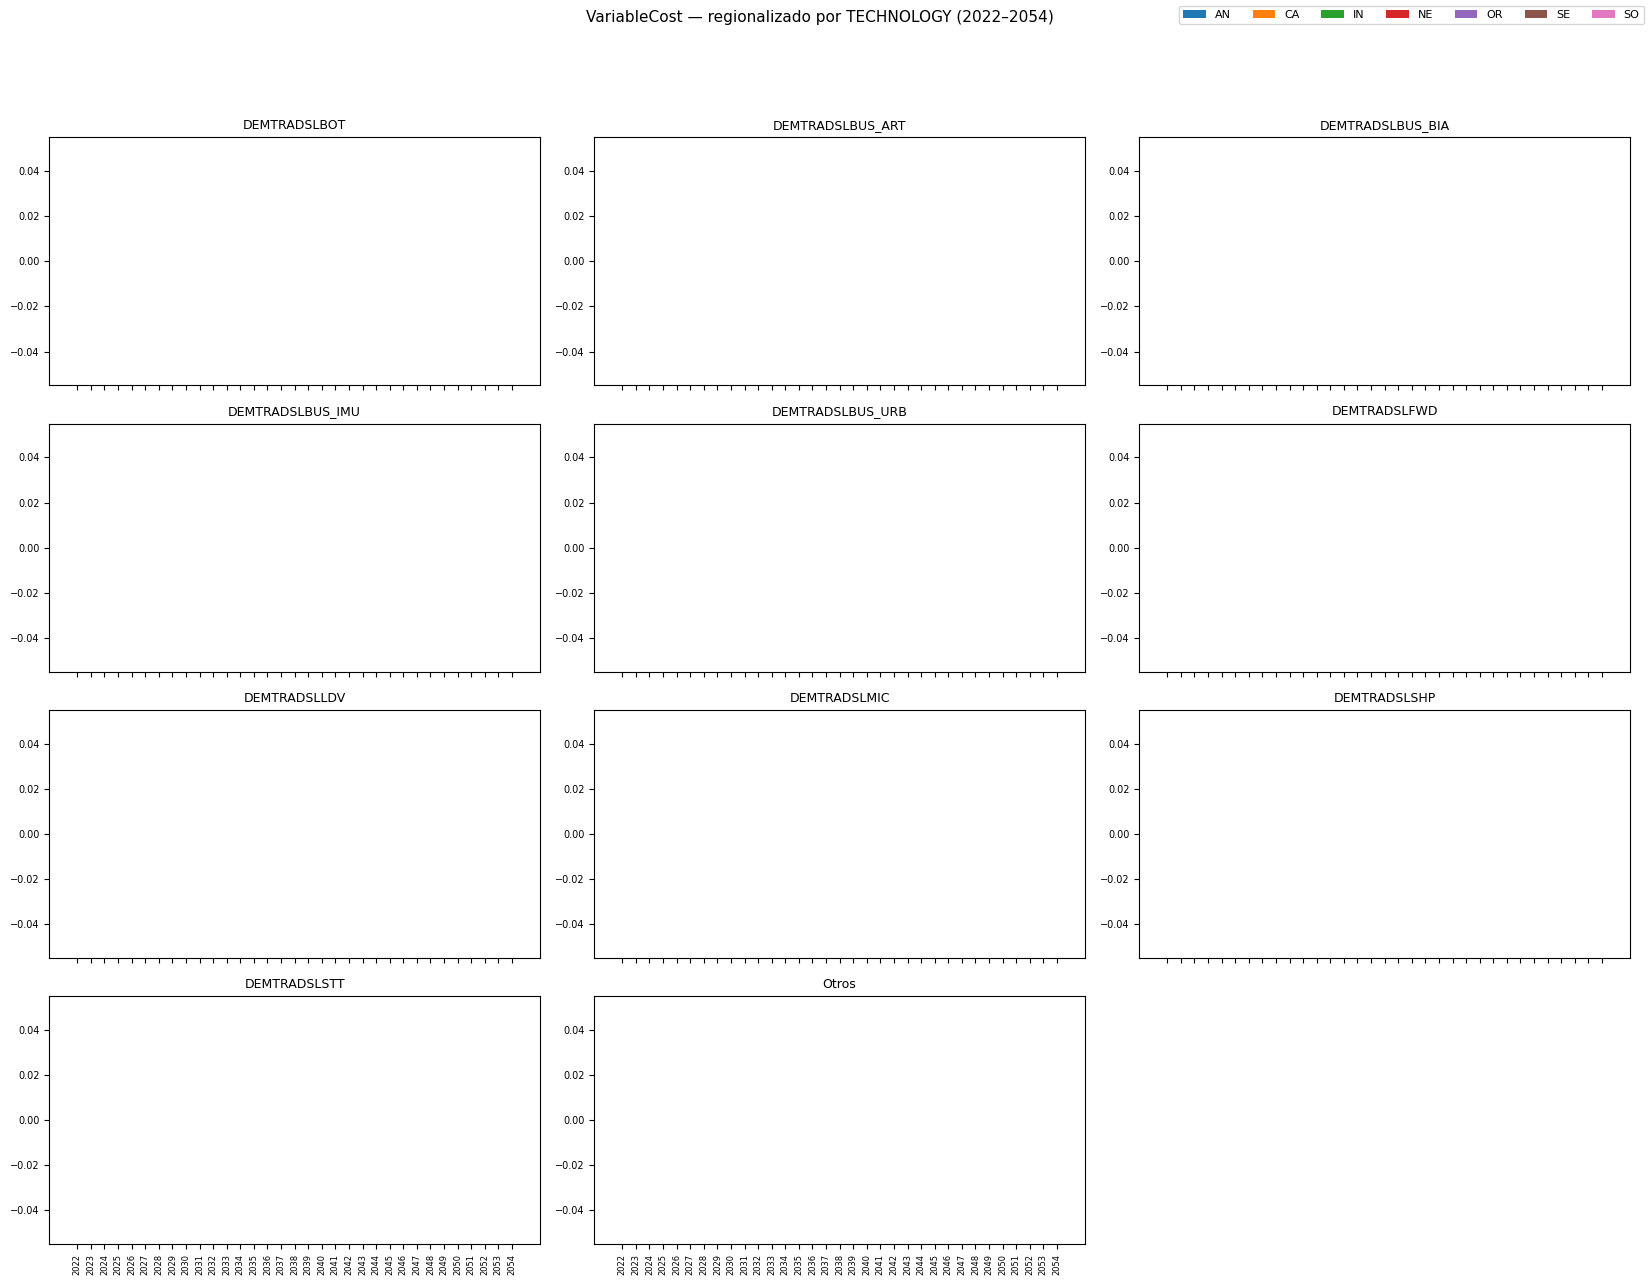

04:17:18 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:18 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:18 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:18 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:17:18 INFO    matplotlib.category: Using categorical units to plot a list of strings 

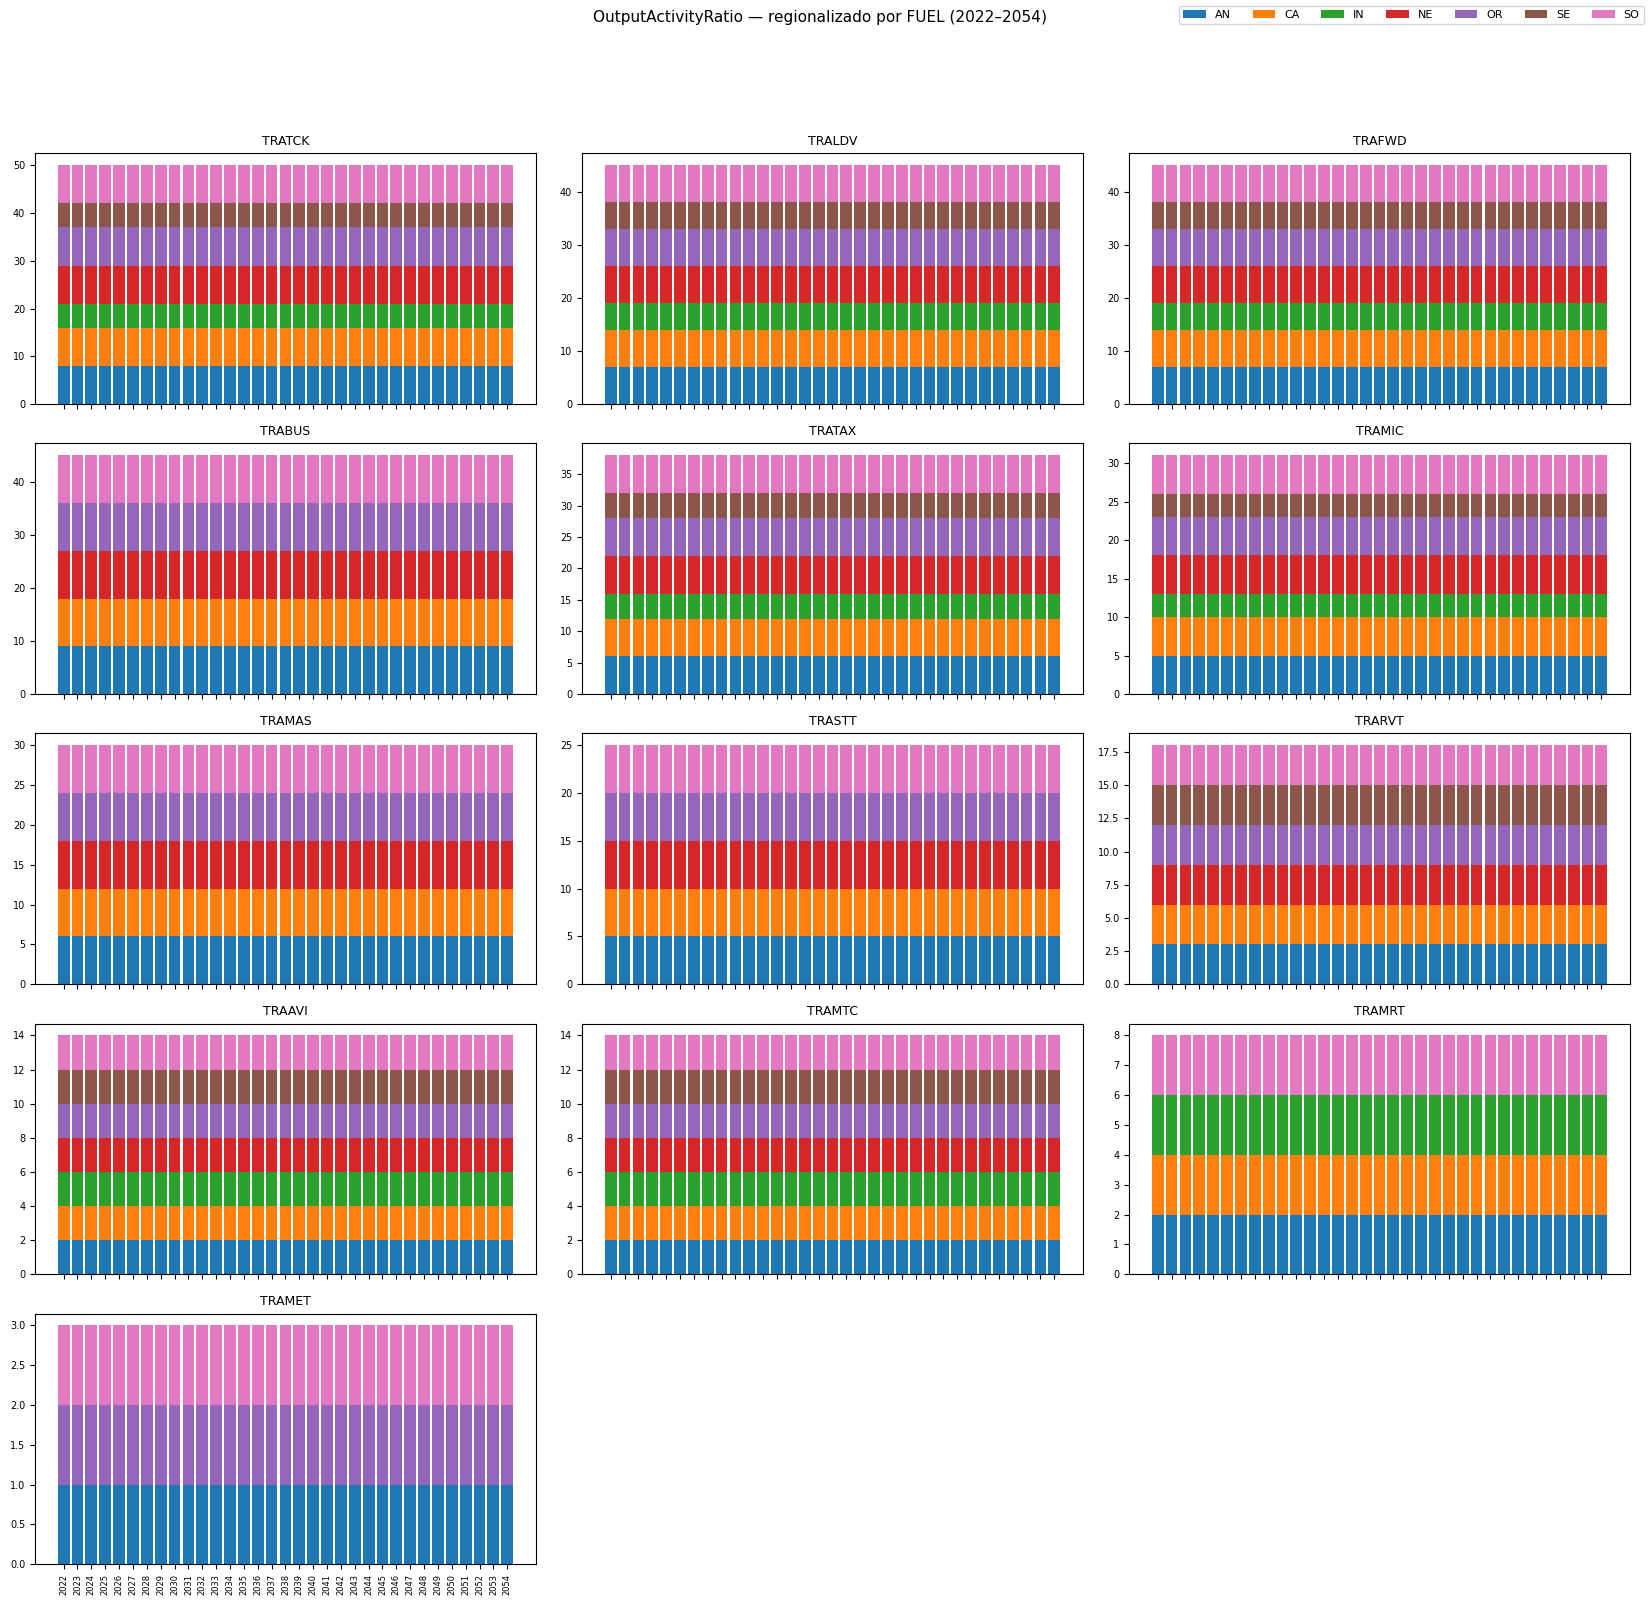

⚠ **InputActivityRatio** no tiene datos regionalizados — revisar `omisiones_regionalizacion.xlsx`

In [ ]:
import matplotlib.pyplot as plt

for parametro in PARAMETROS_A_REGIONALIZAR:
    df_sand = sands.get(parametro)
    if df_sand is None or df_sand.empty:
        display(Markdown(
            f"⚠ **{parametro}** no tiene datos regionalizados — "
            f"revisar `{RUTA_OMISIONES.name}`"))
        continue
    fig = reporte.grafica_control_regionalizacion(
        df_sand, parametro, otoole["param"][parametro]["indices"],
        anios=[str(a) for a in YEARS_FILTRO],
    )
    if fig is None:
        display(Markdown(f"⚠ **{parametro}**: sin valores numéricos para graficar"))
    else:
        plt.show()

## 6. Exportar SANDs reducidos y log

In [ ]:
if MODO_DRY_RUN:
    display(Markdown("**DRY-RUN — no se escribió ningún archivo.** Se habría generado:"))
    carpeta = DIR_SANDS_REDUCIDOS
    if CONSOLIDADO:
        total = sum(len(d) for d in sands.values())
        print(f"  {carpeta / f'SAND_Consolidado_{DESCRIPCION}.xlsx'}  ({total:,} filas)")
    else:
        for parametro, df_sand in sands.items():
            print(f"  {carpeta / f'SAND_{parametro}_{DESCRIPCION}.xlsx'}  ({len(df_sand):,} filas)")
    print(f"  {DIR_REPORTES}/log_regionalizacion_*.xlsx (+ .txt)")
    rutas_sand = []
else:
    rutas_sand = regionalizador.escribir_sands(
        sands, DIR_SANDS_REDUCIDOS, DESCRIPCION, consolidado=CONSOLIDADO,
    )
    for ruta in rutas_sand:
        print(f"SAND : {ruta}")

    # El log lleva adjuntas las decisiones de omisión finales
    log_completo = log.copy()
    ruta_log_xlsx, ruta_log_txt = reporte.escribir_log_regionalizacion(
        log_completo, DIR_REPORTES,
    )
    if not omisiones.empty:
        with pd.ExcelWriter(ruta_log_xlsx, engine="openpyxl", mode="a") as writer:
            omisiones.to_excel(writer, sheet_name="Omisiones", index=False)
    print(f"Log  : {ruta_log_xlsx}")
    print(f"Log  : {ruta_log_txt}")

04:17:30 INFO    regionalizador: SAND escrito: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_TotalAnnualMaxCapacityInvestment_Mapeo.xlsx
04:17:30 INFO    regionalizador: SAND escrito: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_TotalTechnologyAnnualActivityUpperLimit_Mapeo.xlsx
04:17:30 INFO    regionalizador: SAND escrito: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_SpecifiedDemandProfile_Mapeo.xlsx
04:17:30 INFO    regionalizador: SAND escrito: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_CapitalCost_Mapeo.xlsx
04:17:30 INFO    regionalizador: SAND escrito: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_FixedCost_Mapeo.xlsx
04:17:30 INFO    regionalizador: SAND

In [ ]:
# --- Resumen final ---
pedidos = list(PARAMETROS_A_REGIONALIZAR)
con_datos = [p for p in pedidos if p in sands and not sands[p].empty]
parciales = [p for p in con_datos
             if not resumen.loc[resumen["Parametro"] == p, "Combos_Omitidos"].eq(0).all()]
vacios = [p for p in pedidos if p not in con_datos]
filas_totales = int(resumen["Filas_SAND"].sum()) if not resumen.empty else 0

display(Markdown("### Resumen final"))
print(f"Parámetros regionalizados exitosamente : {len(con_datos)}")
print(f"Parámetros con omisiones parciales     : {len(parciales)}"
      + (f" -> {parciales}" if parciales else ""))
print(f"Parámetros omitidos completamente      : {len(vacios)}"
      + (f" -> {vacios}" if vacios else ""))
print(f"Filas SAND generadas en total          : {filas_totales:,}")
if not omisiones.empty:
    # crear_todas / crear_regiones:XX / crear_existentes
    creados = omisiones["Decision"].str.startswith("crear").sum()
    print(f"Omisiones registradas                  : {len(omisiones)} "
          f"({creados} resueltas creando regiones)")
print("\nArchivos exportados:")
if MODO_DRY_RUN:
    print("  SANDs y log: ninguno (MODO_DRY_RUN = True)")
else:
    for ruta in rutas_sand:
        print(f"  {ruta}")
    print(f"  {ruta_log_xlsx}")
    print(f"  {ruta_log_txt}")
if not omisiones.empty:
    # La auditoría de omisiones se escribe siempre, también en dry-run
    print(f"  {RUTA_OMISIONES}  (auditoría, se escribe siempre)")

### Resumen final

Parámetros regionalizados exitosamente : 8
Parámetros con omisiones parciales     : 0
Parámetros omitidos completamente      : 7 -> ['ResidualCapacity', 'AccumulatedAnnualDemand', 'TotalTechnologyAnnualActivityLowerLimit', 'TotalAnnualMinCapacityInvestment', 'TotalTechnologyAnnualActivityLowerLimit', 'SpecifiedAnnualDemand', 'InputActivityRatio']
Filas SAND generadas en total          : 2,565
Omisiones registradas                  : 282 (0 resueltas creando regiones)

Archivos exportados:
  C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_TotalAnnualMaxCapacityInvestment_Mapeo.xlsx
  C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_TotalTechnologyAnnualActivityUpperLimit_Mapeo.xlsx
  C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_SpecifiedDemandProfile_Mapeo.xlsx
  C:\Users\carlo\Documents\05_Gestion_

## Siguiente paso

Integrar los SAND reducidos al escenario regional y convertirlo con otoole:

```bash
otoole convert csv excel CSV_Regional salida.xlsx config_depurado.yaml
```

*Smoke tests de los módulos: `python tests/test_smoke.py` desde la raíz del proyecto.*